# SAE decomposition demo

2D inputs → 5D sparse code → 2D reconstruction. overcomplete (5 features for 2-dim space). decoder columns unit-norm. trained with MSE + L1 sparsity. data is sparse-feature-like: each sample is one true feature direction × random magnitude + small direction noise.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

## true features (5 unit directions in 2D)

5 directions, angularly spaced, unit length. these are what we hope the SAE recovers.

true features (each row = one feature direction, unit length):
[[ 0.955  0.296]
 [ 0.014  1.   ]
 [-0.947  0.322]
 [-0.599 -0.801]
 [ 0.576 -0.817]]


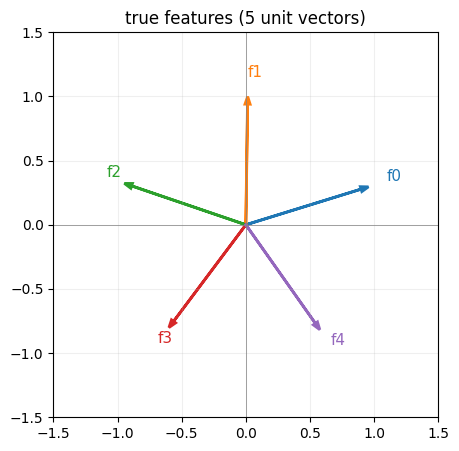

In [2]:
n_features = 5
# (5,) - angles of true features in radians (offset 0.3 just so they're not axis-aligned)
angles = np.linspace(0, 2 * np.pi, n_features, endpoint=False) + 0.3
# (5, 2) - unit direction per true feature
true_features = np.stack([np.cos(angles), np.sin(angles)], axis=1)
print('true features (each row = one feature direction, unit length):')
print(true_features.round(3))

fig, ax = plt.subplots(figsize=(5, 5))
for i, f in enumerate(true_features):
    ax.arrow(0, 0, f[0], f[1], head_width=0.04, color=f'C{i}', length_includes_head=True, lw=2)
    ax.annotate(f'f{i}', f * 1.15, color=f'C{i}', fontsize=11)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_title('true features (5 unit vectors)')
plt.show()

## training data

each sample: pick one of the 5 true features at random, scale by a random magnitude in [0.3, 3.0], add tiny direction noise. no feature combinations — single-feature activations only.

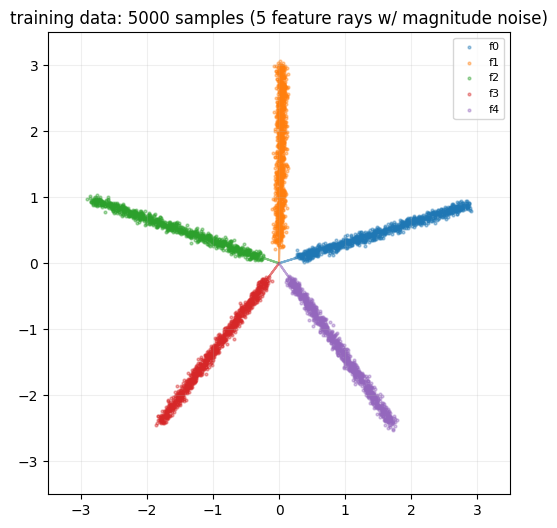

In [3]:
n_samples = 5000
noise_scale = 0.04 # tiny direction perturbation

# (n_samples,) - random magnitudes in [0.3, 3.0]
mags = np.random.uniform(0.3, 3.0, n_samples)
# (n_samples,) - which true feature each sample uses
feat_idx = np.random.randint(0, n_features, n_samples)
# (n_samples, 2) - input data
data = mags[:, None] * true_features[feat_idx] + np.random.randn(n_samples, 2) * noise_scale
data_t = torch.tensor(data, dtype=torch.float32)

# scatter plot of inputs colored by which true feature they came from
fig, ax = plt.subplots(figsize=(6, 6))
for i in range(n_features):
    mask = feat_idx == i
    ax.scatter(data[mask, 0], data[mask, 1], color=f'C{i}', s=4, alpha=0.4, label=f'f{i}')
for i, f in enumerate(true_features):
    ax.arrow(0, 0, f[0] * 3, f[1] * 3, head_width=0.06, color=f'C{i}', alpha=0.6, lw=1.5, length_includes_head=True)
ax.set_xlim(-3.5, 3.5); ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal'); ax.grid(alpha=0.2)
ax.legend(loc='upper right', fontsize=8)
ax.set_title(f'training data: {n_samples} samples (5 feature rays w/ magnitude noise)')
plt.show()

## SAE

- encoder: (5, 2) Linear + bias
- ReLU
- decoder: (2, 5) Linear no bias, columns constrained to unit norm (re-normalized after each step)
- untied weights

In [4]:
# tied weights: single matrix W (shape: d_features x d_in).
# encoder = W (each row is a feature direction read), decoder = W^T (cols write).
# rows of W are normalized to unit norm.
class SAE(nn.Module):
    def __init__(self, d_in=2, d_features=5):
        super().__init__()
        # (d_features, d_in) - shared weight, each row is one feature's direction
        self.W = nn.Parameter(torch.randn(d_features, d_in))
        self.b = nn.Parameter(torch.zeros(d_features))
        # smart init: rows of W on unit circle, evenly spaced
        with torch.no_grad():
            init_angles = np.linspace(0, 2 * np.pi, d_features, endpoint=False)
            init_dirs = np.stack([np.cos(init_angles), np.sin(init_angles)], axis=1) # (d_features, 2)
            self.W.data = torch.tensor(init_dirs, dtype=torch.float32)
        self.normalize()

    def forward(self, x):
        # x: (batch, d_in)
        # encode: (batch, d_in) @ (d_in, d_features) -> (batch, d_features)
        z = F.relu(x @ self.W.T + self.b)
        # decode: (batch, d_features) @ (d_features, d_in) -> (batch, d_in)
        x_hat = z @ self.W
        return x_hat, z

    def normalize(self):
        # constrain each row of W to unit norm (= each feature direction unit length)
        with torch.no_grad():
            self.W.data = self.W.data / (self.W.data.norm(dim=1, keepdim=True) + 1e-8)

sae = SAE(d_in=2, d_features=n_features)
print(sae)

SAE(
  (encoder): Linear(in_features=2, out_features=5, bias=True)
  (decoder): Linear(in_features=5, out_features=2, bias=False)
)


## training

loss = reconstruction MSE + λ · L1(z). decoder columns re-normalized to unit length after each optimizer step.

ep    0: rec=3.9206  l1=0.5393  loss=4.1902
ep  500: rec=0.0120  l1=0.3813  loss=0.2027
ep 1000: rec=0.0110  l1=0.3764  loss=0.1992
ep 1500: rec=0.0104  l1=0.3759  loss=0.1983
ep 2000: rec=0.0098  l1=0.3761  loss=0.1978
ep 2500: rec=0.0108  l1=0.3757  loss=0.1986
ep 3000: rec=0.0098  l1=0.3830  loss=0.2013
ep 3500: rec=0.0107  l1=0.3712  loss=0.1964
ep 4000: rec=0.0117  l1=0.3703  loss=0.1968
ep 4500: rec=0.0105  l1=0.3753  loss=0.1982
ep 4999: rec=0.0095  l1=0.3738  loss=0.1964


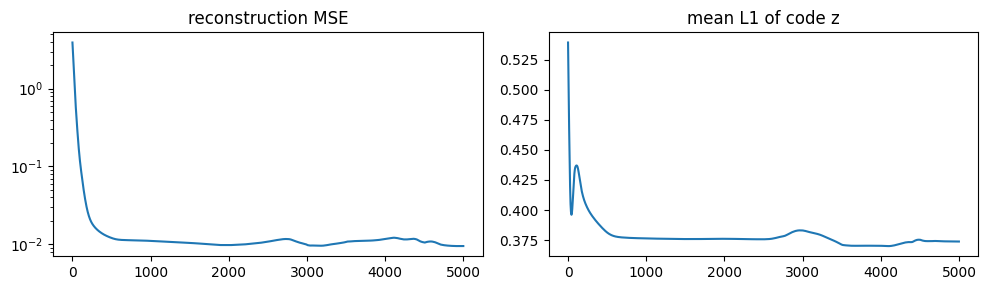

In [5]:
n_epochs = 5000
sparsity_coef = 0.5
lr = 0.01

opt = torch.optim.Adam(sae.parameters(), lr=lr)

history = {'rec': [], 'l1': []} # {str: [float]}
for ep in range(n_epochs):
    x_hat, z = sae(data_t)
    rec = F.mse_loss(x_hat, data_t)
    l1 = z.abs().mean()
    loss = rec + sparsity_coef * l1
    opt.zero_grad(); loss.backward(); opt.step()
    sae.normalize()
    history['rec'].append(rec.item())
    history['l1'].append(l1.item())
    if ep % 500 == 0 or ep == n_epochs - 1:
        print(f'ep {ep:4d}: rec={rec.item():.4f}  l1={l1.item():.4f}  loss={loss.item():.4f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(history['rec']); ax[0].set_title('reconstruction MSE'); ax[0].set_yscale('log')
ax[1].plot(history['l1']); ax[1].set_title('mean L1 of code z')
plt.tight_layout(); plt.show()

## visualize encoder + decoder vs true features

expect: decoder columns (unit norm by construction) align with true feature directions; encoder rows align too but with variable magnitude (they're projections, not unit).

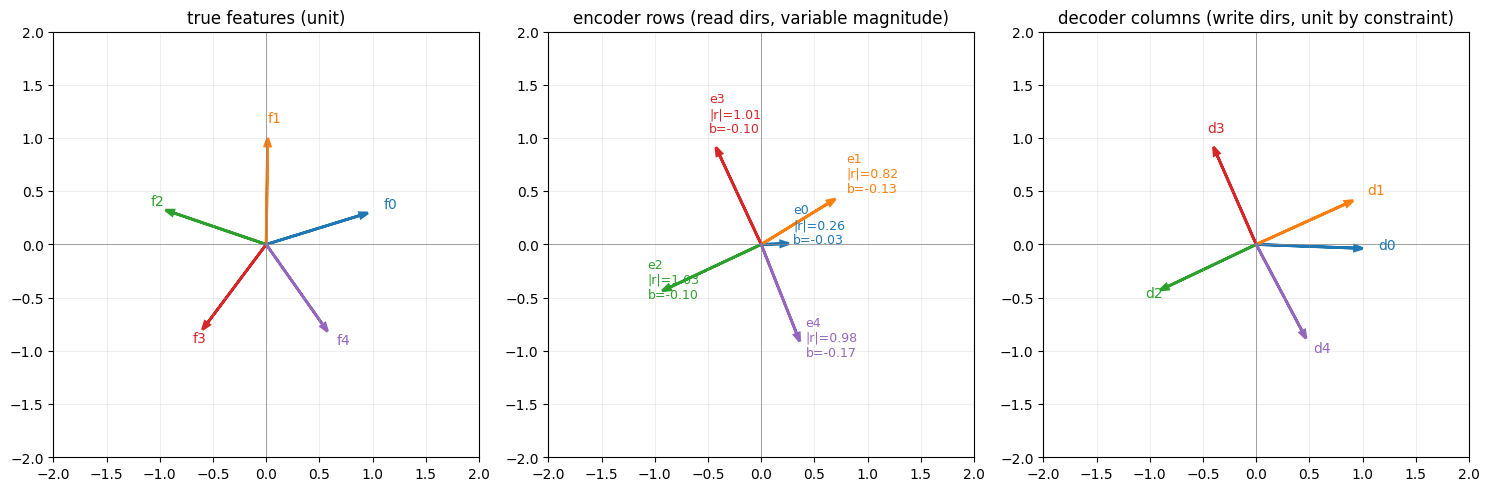

decoder col vs true feature cosine similarity (rows=decoder, cols=true):
[[ 0.94 -0.02 -0.96 -0.57  0.61]
 [ 0.99  0.43 -0.73 -0.88  0.19]
 [-0.99 -0.44  0.72  0.88 -0.17]
 [-0.11  0.91  0.68 -0.49 -0.98]
 [ 0.19 -0.88 -0.73  0.43  0.99]]


In [6]:
W_enc = sae.W.detach().numpy() # (5, 2) - rows = feature dirs (read)
b_enc = sae.b.detach().numpy()   # (5,)
W_dec = sae.W.T.detach().numpy() # (2, 5) - cols = feature dirs (write)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax in axes:
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal'); ax.grid(alpha=0.2)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)

# panel 1: true features
axes[0].set_title('true features (unit)')
for i, f in enumerate(true_features):
    axes[0].arrow(0, 0, f[0], f[1], head_width=0.05, color=f'C{i}', length_includes_head=True, lw=2)
    axes[0].annotate(f'f{i}', f * 1.15, color=f'C{i}', fontsize=10)

# panel 2: encoder rows (read directions, may not be unit)
axes[1].set_title('encoder rows (read dirs, variable magnitude)')
for i in range(n_features):
    r = W_enc[i]
    axes[1].arrow(0, 0, r[0], r[1], head_width=0.05, color=f'C{i}', length_includes_head=True, lw=2)
    axes[1].annotate(f'e{i}\n|r|={np.linalg.norm(r):.2f}\nb={b_enc[i]:.2f}', r * 1.15, color=f'C{i}', fontsize=9)

# panel 3: decoder columns (write dirs, unit by construction)
axes[2].set_title('decoder columns (write dirs, unit by constraint)')
for i in range(n_features):
    d = W_dec[:, i]
    axes[2].arrow(0, 0, d[0], d[1], head_width=0.05, color=f'C{i}', length_includes_head=True, lw=2)
    axes[2].annotate(f'd{i}', d * 1.15, color=f'C{i}', fontsize=10)

plt.tight_layout(); plt.show()

# how much does each decoder column align with each true feature (cosine similarity)
# (5, 5) - decoder col j vs true feature i
true_norm = true_features / np.linalg.norm(true_features, axis=1, keepdims=True)
dec_norm = (W_dec / np.linalg.norm(W_dec, axis=0, keepdims=True)).T # (5, 2)
cos_sim = dec_norm @ true_norm.T # (5, 5) - decoder_idx, true_idx
print('decoder col vs true feature cosine similarity (rows=decoder, cols=true):')
print(cos_sim.round(2))

## forward pass per true feature

feed each true feature direction (unit length) through the SAE. ideal: encoder produces a near-one-hot 5d code (single feature active), decoder reconstructs the input.

In [7]:
print('per-true-feature forward pass (input = unit feature):\n')
for i, f in enumerate(true_features):
    x = torch.tensor(f, dtype=torch.float32).unsqueeze(0) # (1, 2)
    x_hat, z = sae(x)
    z_arr = z[0].detach().numpy()
    rec = x_hat[0].detach().numpy()
    print(f'true feature {i}: input = {f.round(3)}')
    print(f'  encoder out (5d):    {z_arr.round(3)}')
    print(f'  active features:     {np.where(z_arr > 0.01)[0].tolist()}')
    print(f'  decoder reconstruct: {rec.round(3)}  (input was {f.round(3)})')
    print(f'  reconstruction err:  {np.linalg.norm(rec - f):.4f}')
    print()

per-true-feature forward pass (input = unit feature):

true feature 0: input = [0.955 0.296]
  encoder out (5d):    [0.215 0.663 0.    0.    0.   ]
  active features:     [0, 1]
  decoder reconstruct: [0.819 0.266]  (input was [0.955 0.296])
  reconstruction err:  0.1397

true feature 1: input = [0.014 1.   ]
  encoder out (5d):    [0.    0.308 0.    0.806 0.   ]
  active features:     [1, 3]
  decoder reconstruct: [-0.043  0.865]  (input was [0.014 1.   ])
  reconstruction err:  0.1464

true feature 2: input = [-0.947  0.322]
  encoder out (5d):    [0.    0.    0.634 0.596 0.   ]
  active features:     [2, 3]
  decoder reconstruct: [-0.812  0.273]  (input was [-0.947  0.322])
  reconstruction err:  0.1434

true feature 3: input = [-0.599 -0.801]
  encoder out (5d):    [0.    0.    0.801 0.    0.345]
  active features:     [2, 4]
  decoder reconstruct: [-0.562 -0.649]  (input was [-0.599 -0.801])
  reconstruction err:  0.1565

true feature 4: input = [ 0.576 -0.817]
  encoder out (5d):

## magnitude variation

for true feature 0: scale by varying magnitudes. ideal: the active SAE feature's value scales with input magnitude (positive homogeneity within the active region; the shifted ReLU bias creates a threshold).

In [8]:
print('magnitude scan along true feature 0:\n')
f0 = true_features[0]
for mag in [0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 3.0]:
    x = torch.tensor(mag * f0, dtype=torch.float32).unsqueeze(0)
    x_hat, z = sae(x)
    z_arr = z[0].detach().numpy()
    print(f'mag {mag:4.1f}: code = {z_arr.round(3)}  recon mag = {np.linalg.norm(x_hat[0].detach().numpy()):.3f}')

magnitude scan along true feature 0:

mag  0.1: code = [0. 0. 0. 0. 0.]  recon mag = 0.000
mag  0.3: code = [0.04  0.109 0.    0.    0.   ]  recon mag = 0.146
mag  0.5: code = [0.09  0.267 0.    0.    0.   ]  recon mag = 0.350
mag  1.0: code = [0.215 0.663 0.    0.    0.   ]  recon mag = 0.861
mag  1.5: code = [0.34  1.059 0.    0.    0.   ]  recon mag = 1.372
mag  2.0: code = [0.465 1.456 0.    0.    0.   ]  recon mag = 1.883
mag  3.0: code = [0.714 2.248 0.    0.    0.062]  recon mag = 2.916


## direction variation

for true feature 0: rotate slightly off-axis. see how the encoder's selectivity degrades — at some angle the wrong feature starts firing.

In [9]:
print('direction scan around true feature 0 (unit magnitude):\n')
base_angle = angles[0]
for delta_deg in [-30, -15, -5, 0, 5, 15, 30, 45]:
    a = base_angle + np.deg2rad(delta_deg)
    v = np.array([np.cos(a), np.sin(a)])
    x = torch.tensor(v, dtype=torch.float32).unsqueeze(0)
    _, z = sae(x)
    z_arr = z[0].detach().numpy()
    active = np.where(z_arr > 0.01)[0].tolist()
    print(f'  Δ={delta_deg:+4d}°:  code = {z_arr.round(3)}  active = {active}')

direction scan around true feature 0 (unit magnitude):

  Δ= -30°:  code = [0.216 0.456 0.    0.    0.388]  active = [0, 1, 4]
  Δ= -15°:  code = [0.224 0.584 0.    0.    0.159]  active = [0, 1, 4]
  Δ=  -5°:  code = [0.22  0.643 0.    0.    0.   ]  active = [0, 1]
  Δ=  +0°:  code = [0.215 0.663 0.    0.    0.   ]  active = [0, 1]
  Δ=  +5°:  code = [0.208 0.678 0.    0.    0.   ]  active = [0, 1]
  Δ= +15°:  code = [0.188 0.689 0.    0.025 0.   ]  active = [0, 1, 3]
  Δ= +30°:  code = [0.147 0.658 0.    0.28  0.   ]  active = [0, 1, 3]
  Δ= +45°:  code = [0.093 0.574 0.    0.508 0.   ]  active = [0, 1, 3]


## takeaway

- decoder columns (unit, free angle) recover the true feature directions because reconstruction loss + L1 + sparsity + overcomplete basis push that way
- encoder rows align with the same directions but their magnitude controls how strongly the feature fires per unit of input alignment (not unit by construction)
- bias terms shift the ReLU threshold per feature
- single-feature inputs activate (mostly) one SAE feature; off-direction inputs start activating multiple as the angle widens